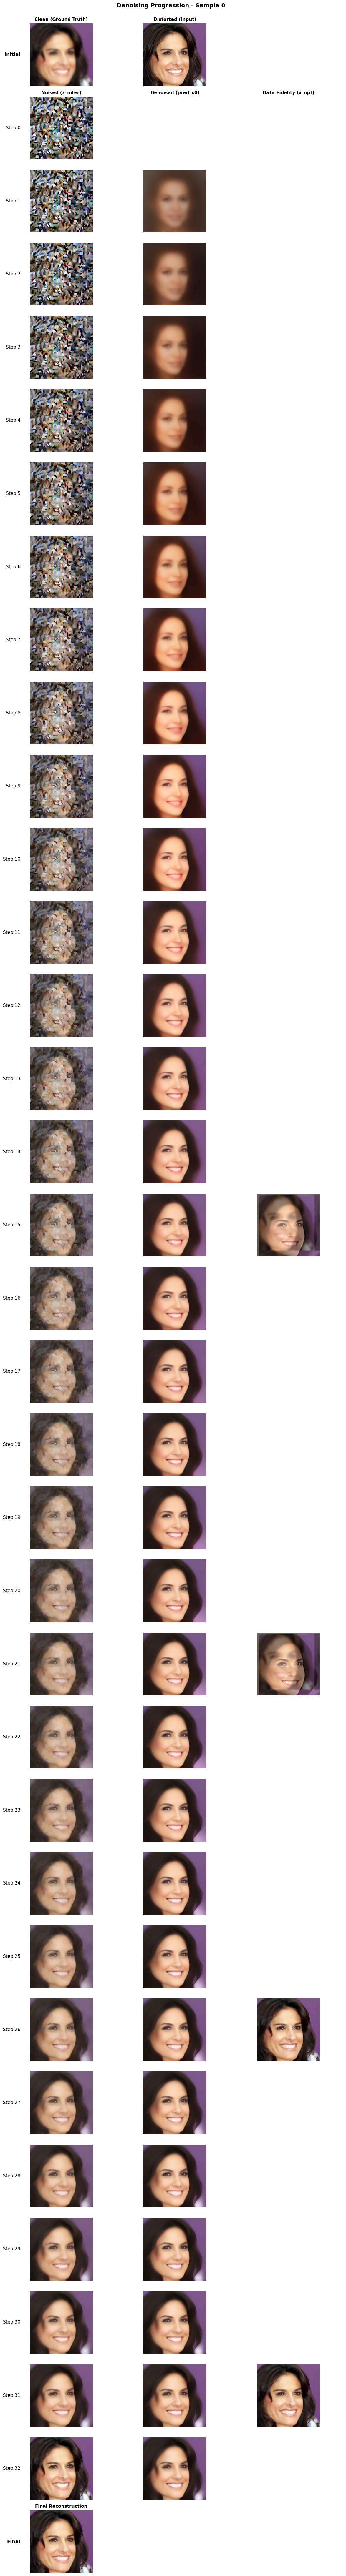

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from typing import Union, List, Optional

def visualize_denoising_progress(
    results_dir: Union[str, Path],
    sample_indices: Union[int, List[int]],
    figsize: Optional[tuple] = None,
    save_path: Optional[str] = None
):
    """
    Visualize the denoising progression for samples from an experiment directory.
    
    The function displays a grid showing the complete denoising process:
    - Row 0: Clean (label) and Distorted (input) images
    - Rows 1 to N: Intermediate steps showing (x_inter, pred_x0, x_opt) triplets
    - Last row: Final reconstructed image
    
    Parameters:
    -----------
    results_dir : str or Path
        Parent directory containing 'progress/', 'input/', 'label/', and 'recon/' folders
    sample_indices : int or list of int
        Sample index/indices to visualize (e.g., 0, 1, or [0, 1])
    figsize : tuple, optional
        Figure size (width, height). Auto-calculated if None
    save_path : str, optional
        Path to save the figure. If None, only displays
        
    Directory structure expected:
        results_dir/
            input/       # Distorted input images
            label/       # Clean ground truth images
            recon/       # Final reconstructed images
            progress/    # Intermediate steps
                {sample_id}_x_inter_{step}.png
                {sample_id}_pred_x0_{step}.png
                {sample_id}_x_opt_{step}.png
    """
    results_dir = Path(results_dir)
    
    # Handle single index or list
    if isinstance(sample_indices, int):
        sample_indices = [sample_indices]
    
    # Process each sample
    for sample_idx in sample_indices:
        _visualize_single_sample(results_dir, sample_idx, sample_indices, figsize, save_path)


def _visualize_single_sample(
    results_dir: Path,
    sample_idx: int,
    all_indices: List[int],
    figsize: Optional[tuple] = None,
    save_path: Optional[str] = None
):
    """Visualize progression for a single sample."""
    
    progress_dir = results_dir / "progress"
    input_dir = results_dir / "input"
    label_dir = results_dir / "label"
    recon_dir = results_dir / "recon"
    
    # Format sample ID as 3-digit string
    sample_id = f"{sample_idx:03d}"
    
    # Find all step numbers for this sample
    inter_files = sorted(progress_dir.glob(f"{sample_id}_x_inter_*.png"))
    steps = []
    for f in inter_files:
        step_str = f.stem.split('_')[-1]
        steps.append(int(step_str))
    steps.sort()
    
    if not steps:
        print(f"No progress images found for sample {sample_idx}")
        return
    
    num_steps = len(steps)
    
    # Total rows: 1 (input/label) + num_steps (progress) + 1 (recon)
    nrows = num_steps + 2
    ncols = 3
    
    if figsize is None:
        figsize = (4 * ncols, 2.5 * nrows)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    
    # Ensure axes is 2D even with single row (shouldn't happen here but defensive)
    if nrows == 1:
        axes = axes.reshape(1, -1)
    
    # Helper to load and display image
    def show_image(ax, img_path, title=""):
        if img_path and img_path.exists():
            img = Image.open(img_path)
            ax.imshow(img)
            if title:
                ax.set_title(title, fontsize=11, fontweight='bold')
        ax.axis('off')
    
    # Row 0: Clean (label) and Distorted (input)
    label_path = label_dir / f"{sample_id}_label.png"
    input_path = input_dir / f"{sample_id}_true.png"
    
    show_image(axes[0, 0], label_path, "Clean (Ground Truth)")
    show_image(axes[0, 1], input_path, "Distorted (Input)")
    axes[0, 2].axis('off')  # Empty third column
    
    # Add row label for initial row
    axes[0, 0].text(-0.15, 0.5, "Initial", transform=axes[0, 0].transAxes,
                    fontsize=12, fontweight='bold', va='center', ha='right')
    
    # Rows 1 to num_steps: Progress triplets
    for i, step in enumerate(steps):
        row_idx = i + 1
        
        inter_path = progress_dir / f"{sample_id}_x_inter_{step}.png"
        pred_path = progress_dir / f"{sample_id}_pred_x0_{step}.png"
        opt_path = progress_dir / f"{sample_id}_x_opt_{step}.png"
        
        # Column titles only on first progress row
        title_inter = "Noised (x_inter)" if i == 0 else ""
        title_pred = "Denoised (pred_x0)" if i == 0 else ""
        title_opt = "Data Fidelity (x_opt)" if i == 0 else ""
        
        show_image(axes[row_idx, 0], inter_path, title_inter)
        if row_idx > 1:
            show_image(axes[row_idx, 1], pred_path, title_pred)
        else:
            axes[row_idx, 1].axis('off')
            axes[row_idx, 1].set_title(title_pred, fontsize=11, fontweight='bold')
            
        # x_opt may not exist for all steps
        if opt_path.exists():
            show_image(axes[row_idx, 2], opt_path, title_opt)
        else:
            axes[row_idx, 2].axis('off')
            axes[row_idx, 2].set_title(title_opt, fontsize=11, fontweight='bold')
        
        # Row label with step number using text
        axes[row_idx, 0].text(-0.15, 0.5, f"Step {step}", transform=axes[row_idx, 0].transAxes,
                              fontsize=11, va='center', ha='right')
    
    # Last row: Reconstructed image
    recon_path = recon_dir / f"{sample_id}_recon.png"
    last_row = nrows - 1
    
    show_image(axes[last_row, 0], recon_path, "Final Reconstruction")
    axes[last_row, 1].axis('off')
    axes[last_row, 2].axis('off')
    
    # Add row label for final row
    axes[last_row, 0].text(-0.15, 0.5, "Final", transform=axes[last_row, 0].transAxes,
                           fontsize=12, fontweight='bold', va='center', ha='right')
    
    # Main title
    fig.suptitle(f"Denoising Progression - Sample {sample_idx}", fontsize=14, fontweight='bold', y=1.0)
    
    plt.tight_layout()
    
    if save_path:
        # If multiple samples, append sample index to filename
        if len(all_indices) > 1:
            save_base = Path(save_path)
            save_with_idx = save_base.parent / f"{save_base.stem}_sample{sample_idx}{save_base.suffix}"
            fig.savefig(save_with_idx, bbox_inches='tight', dpi=150)
        else:
            fig.savefig(save_path, bbox_inches='tight', dpi=150)
    
    plt.show()


# Example usage:
if __name__ == "__main__":
    # Visualize single sample
    visualize_denoising_progress(
        results_dir="/media/embedded/Users/Nisim/MSc/AdvancedTopicImageandSP/final_project/shortcut_resample/shortcut-models/results/tests/2sample_every5_32steps",
        sample_indices=0
    )
    
#     # Visualize multiple samples
#     visualize_denoising_progress(
#         results_dir="/media/embedded/Users/Nisim/MSc/AdvancedTopicImageandSP/final_project/shortcut_resample/shortcut-models/results/tests/2_latest_32steps",
#         sample_indices=[0, 1],
#         save_path="denoising_viz.png"
#     )